In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer



In [ ]:
df=pd.read_csv("Titanic.csv")

df.sample(12)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
228,229,0,2,"Fahlstrom, Mr. Arne Jonas",male,18.0,0,0,236171,13.0000,NaN,S
73,74,0,3,"Chronopoulos, Mr. Apostolos",male,26.0,1,0,2680,14.4542,NaN,C
434,435,0,1,"Silvey, Mr. William Baird",male,50.0,1,0,13507,55.9000,E44,S
565,566,0,3,"Davies, Mr. Alfred J",male,24.0,2,0,A/4 48871,24.1500,NaN,S
473,474,1,2,"Jerwan, Mrs. Amin S (Marie Marthe Thuillard)",female,23.0,0,0,SC/AH Basle 541,13.7917,D,C
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
804,805,1,3,"Hedman, Mr. Oskar Arvid",male,27.0,0,0,347089,6.9750,NaN,S
251,252,0,3,"Strom, Mrs. Wilhelm (Elna Matilda Persson)",female,29.0,1,1,347054,10.4625,G6,S
588,589,0,3,"Gilinski, Mr. Eliezer",male,22.0,0,0,14973,8.0500,NaN,S
446,447,1,2,"Mellinger, Miss. Madeleine Violet",female,13.0,0,1,250644,19.5000,NaN,S


In [ ]:

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


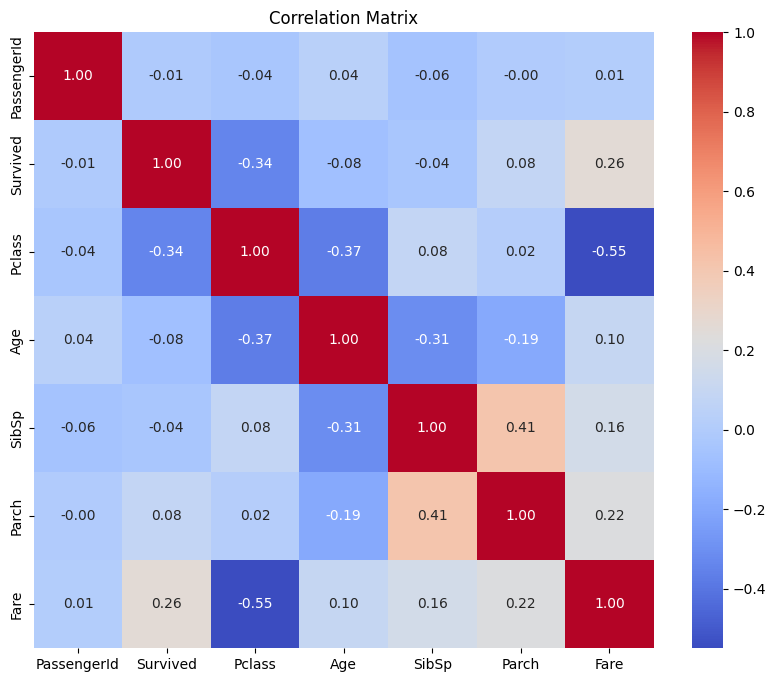

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()


In [ ]:
# prepocessing stage
df.drop(['PassengerId','Name','Ticket'],axis=1,inplace=True)

df["family_size"]=df["SibSp"]+df["Parch"]+1


df.drop(["SibSp","Parch"],axis=1,inplace=True)

In [ ]:
df

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,family_size
0,0,3,male,22.0,7.2500,NaN,S,2
1,1,1,female,38.0,71.2833,C85,C,2
2,1,3,female,26.0,7.9250,NaN,S,1
3,1,1,female,35.0,53.1000,C123,S,2
4,0,3,male,35.0,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,NaN,S,1
887,1,1,female,19.0,30.0000,B42,S,1
888,0,3,female,NaN,23.4500,NaN,S,4
889,1,1,male,26.0,30.0000,C148,C,1


In [ ]:
df["Pclass"].unique()

array([3, 1, 2])

In [ ]:
df["Pclass"].unique()
df["Fare"].unique()

array([  7.25  ,  71.2833,   7.925 ,  53.1   ,   8.05  ,   8.4583,
        51.8625,  21.075 ,  11.1333,  30.0708,  16.7   ,  26.55  ,
        31.275 ,   7.8542,  16.    ,  29.125 ,  13.    ,  18.    ,
         7.225 ,  26.    ,   8.0292,  35.5   ,  31.3875, 263.    ,
         7.8792,   7.8958,  27.7208, 146.5208,   7.75  ,  10.5   ,
        82.1708,  52.    ,   7.2292,  11.2417,   9.475 ,  21.    ,
        41.5792,  15.5   ,  21.6792,  17.8   ,  39.6875,   7.8   ,
        76.7292,  61.9792,  27.75  ,  46.9   ,  80.    ,  83.475 ,
        27.9   ,  15.2458,   8.1583,   8.6625,  73.5   ,  14.4542,
        56.4958,   7.65  ,  29.    ,  12.475 ,   9.    ,   9.5   ,
         7.7875,  47.1   ,  15.85  ,  34.375 ,  61.175 ,  20.575 ,
        34.6542,  63.3583,  23.    ,  77.2875,   8.6542,   7.775 ,
        24.15  ,   9.825 ,  14.4583, 247.5208,   7.1417,  22.3583,
         6.975 ,   7.05  ,  14.5   ,  15.0458,  26.2833,   9.2167,
        79.2   ,   6.75  ,  11.5   ,  36.75  ,   7.7958,  12.5

In [ ]:
from numpy._core import numeric

num_col = df.select_dtypes(include=['int64','float64']).columns

print(num_col)  #sob nite prbo na


Index(['Survived', 'Pclass', 'Age', 'Fare', 'family_size'], dtype='object')


In [ ]:
number_col=['Age', 'Fare', 'family_size']
cat_col=['Sex','Embarked','Pclass',]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline=Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(drop="first"))
])

In [ ]:
preprocessor=ColumnTransformer([
    ("num",num_pipeline,number_col),
    ("cat",cat_pipeline,cat_col)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'family_size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first'))]),
                                 ['Sex', 'Embarked', 'Pclass'])])

In [ ]:
X=df.drop("Survived",axis=1)

y=df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
#model creation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Lr = Pipeline([
    ("prepocessor",preprocessor), # pora datset er prepocessor er under cole gese er lr use
    ("model_1",LogisticRegression())
]
)

Lr.fit(X_train,y_train)

y_pred = Lr.predict(X_test)

print("Logistic regressor\n")
accuray=accuracy_score(y_test,y_pred)
print("accuracy :",accuray)
precission=precision_score(y_test,y_pred)
print("precission",precission)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1_score=f1_score(y_test,y_pred)
print("f1 score  :" ,f1_score)


Logistic regressor

accuracy : 0.7932960893854749
precission 0.7666666666666667
recall : 0.6666666666666666
f1 score  : 0.7131782945736435


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
random_forest_model = Pipeline([
    ("prepocessor",preprocessor),
    ("model_2",RandomForestClassifier(
        n_estimators=300,
        random_state=42,
    ))
]
)
random_forest_model.fit(X_train,y_train)

y_pred = random_forest_model.predict(X_test)

print("Random forest classifier : \n")
accuray=accuracy_score(y_test,y_pred)
print("accuracy :",accuray)

precission=precision_score(y_test,y_pred)
print("precission",precission)

recall=recall_score(y_test,y_pred)
print("recall :",recall)

f1_score=f1_score(y_test,y_pred)
print("f1 score  :" ,f1_score)

Random forest classifier : 

accuracy : 0.8100558659217877
precission 0.7966101694915254
recall : 0.6811594202898551
f1 score  : 0.734375


In [ ]:
# KNN_WITH_GRIDSEARCH HYPERPERAMETR  TUNNING

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

knn_with_grid=Pipeline([
    ("prepocessor",preprocessor),
    ("model_3",KNeighborsClassifier())
])
grid_param={
    "model_3__n_neighbors":[3,4,6,9,11,12,16],
    "model_3__weights":["uniform","distance"],
    "model_3__p":[1,2]
}

grid_search=GridSearchCV(
    estimator=knn_with_grid,
    param_grid=grid_param,
    cv=5,
    scoring="accuracy"
     )


#trainning phase
grid_search.fit(X_train,y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)




Best Parameters: {'model_3__n_neighbors': 12, 'model_3__p': 1, 'model_3__weights': 'uniform'}
Best Cross Validation Accuracy: 0.8231458682162908


In [ ]:

print("KNN with grid seach :")
y_pred=grid_search.predict(X_test)

accuray=accuracy_score(y_test,y_pred)
print("accuracy :",accuray)
precission=precision_score(y_test,y_pred)
print("precission",precission)
recall=recall_score(y_test,y_pred)
print("recall :",recall)
f1_score=f1_score(y_test,y_pred)
print("f1 score  :" ,f1_score)

KNN with grid seach :
accuracy : 0.7877094972067039
precission 0.803921568627451
recall : 0.5942028985507246
f1 score  : 0.6833333333333333


In [ ]:
# LR + PCA
from sklearn.decomposition import PCA

pipe_with_pca = Pipeline([
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=400))
])


pipe_with_pca.fit(X_train ,y_train)
y_pred_with_pca=pipe_with_pca.predict(X_test)

acc_with_pca=accuracy_score(y_test,y_pred_with_pca)


print("Accuracy (With PCA):",acc_with_pca)


Accuracy (With PCA): 0.776536312849162


In [ ]:
from sklearn.tree import DecisionTreeClassifier
decision_tree=Pipeline([
    ("preprocessor",preprocessor),
    ("model_5",DecisionTreeClassifier(random_state=42))
])
decision_tree.fit(X_train,y_train)

y_pred=decision_tree.predict(X_test)
print("Decision tree classifier : \n")
accuray=accuracy_score(y_test,y_pred)
print("accuracy :",accuray)
precission=precision_score(y_test,y_pred)
print("precission",precission)
recall=recall_score(y_test,y_pred)
print("recall :",recall)

Decision tree classifier : 

accuracy : 0.7932960893854749
precission 0.7424242424242424
recall : 0.7101449275362319
